# CMI-Flu EDA
**Dataset:** CMI-Flu Data Resource — Influenza Vaccine Immune Response

**Tables covered:**
- `train_array` — Microarray gene expression (long format: participant × timepoint × gene)
- `train_flow` — Flow cytometry cell population measurements (long format)
- `train_participants` — Participant/cohort metadata (one row per participant-study combination)

---
### Table of Contents
1. [Imports & Data Loading](#1)
2. [Shape & Missing Values](#2)
3. [Data Types](#3)
4. [Table Previews](#4)
5. [Numeric Summary Statistics](#5)
6. [Categorical Column Summaries](#6)
7. [Data Quality Issues & Fixes](#7)
8. [Timepoint Coverage](#8)
9. [Participant Overlap Across Tables](#9)
10. [Longitudinal Subjects (Multi-Season Participants)](#10)
11. [Participant Demographics](#11)
12. [Flow Cytometry — Unit-Stratified Distributions](#12)
13. [Gene Expression — Distribution by Platform](#13)
14. [Missing Value Heatmaps](#14)
15. [Timepoint Deep-Dive](#15)
16. [EDA Summary & Key Findings](#16)
17. [Export Cleaned Data](#17)


---
## 1. Imports & Data Loading <a id='1'></a>

In [1]:
from itertools import combinations

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [2]:
DATA_PATH = 'data/PART2-26-01-26_reorg/PART2-26-01-26_reorg'

train_array = pd.read_csv(DATA_PATH + '/train_array.tsv', sep='\t')
train_flow = pd.read_csv(DATA_PATH + '/train_flow.tsv', sep='\t', low_memory=False)
train_participants = pd.read_csv(DATA_PATH + '/train_participants.tsv', sep='\t')

tables = {
    'train_array': train_array,
    'train_flow': train_flow,
    'train_participants': train_participants,
}

print('Tables loaded successfully.')
for name, df in tables.items():
    print(f'  {name}: {df.shape[0]:,} rows × {df.shape[1]} columns')

Tables loaded successfully.
  train_array: 16,112,494 rows × 7 columns
  train_flow: 213,624 rows × 9 columns
  train_participants: 3,960 rows × 17 columns


---
## 2. Shape & Missing Values <a id='2'></a>
For each table we print the row/column counts, then list every column that has at least one missing value, along with the count and percentage.

In [3]:
for name, df in tables.items():
    print(f'===============================')
    print(f'TABLE: {name}')
    print(f'{df.shape[0]:,} rows, {df.shape[1]} columns')
    print(f'===============================')

    missing_counts = df.isnull().sum()
    missing_only = missing_counts[missing_counts > 0].sort_values(ascending=False)

    if len(missing_only) > 0:
        print('Columns with missing values:')
        for col, count in missing_only.items():
            pct = (count / len(df)) * 100
            print(f'  - {col}: {count:,} missing ({pct:.2f}%)')
    else:
        print('  (No missing values found)')

    print('\n')

TABLE: train_array
16,112,494 rows, 7 columns
Columns with missing values:
  - value: 427 missing (0.00%)


TABLE: train_flow
213,624 rows, 9 columns
Columns with missing values:
  - parent_population: 107,286 missing (50.22%)
  - name: 83,841 missing (39.25%)
  - value: 44 missing (0.02%)


TABLE: train_participants
3,960 rows, 17 columns
Columns with missing values:
  - main_publication_author: 1,883 missing (47.55%)
  - geolocation: 799 missing (20.18%)
  - pubmed_ids: 121 missing (3.06%)
  - main_pmid: 121 missing (3.06%)




---
## 3. Data Types <a id='3'></a>
Shows what dtype pandas inferred for each column (numeric, string/object, bool, etc.).

In [4]:
for name, df in tables.items():
    print(f"\n{'=' * 50}")
    print(f'TABLE: {name} — Column Types')
    print(f"{'=' * 50}")
    print('Type summary:')
    print(df.dtypes.value_counts().to_string())
    print('\nAll column types:')
    print(df.dtypes.to_string())


TABLE: train_array — Column Types
Type summary:
object     5
int64      1
float64    1

All column types:
marray_id          object
participant_id     object
timepoint           int64
gene_symbol        object
value             float64
platform_id        object
material           object

TABLE: train_flow — Column Types
Type summary:
object     6
float64    2
int64      1

All column types:
flow_id                   int64
participant_id           object
timepoint               float64
parent_population        object
population_defnition     object
name                     object
unit                     object
value                   float64
material                 object

TABLE: train_participants — Column Types
Type summary:
object    15
int64      2

All column types:
participant_id             object
subject                    object
biological_sex             object
race                       object
min_age                     int64
max_age                     int64
geolocation 

---
## 4. Table Previews <a id='4'></a>
A quick `.head()` to visually confirm the structure looks as expected.

In [5]:
for name, df in tables.items():
    print(f"\n{'=' * 50}")
    print(f'TABLE: {name}')
    print(f"{'=' * 50}")
    display(df.head(5))


TABLE: train_array


,marray_id,participant_id,timepoint,gene_symbol,value,platform_id,material
0,BS_MARRAY___SDY61.SUB112830__ARM457.Day0__A1BG,SDY61.SUB112830,0,A1BG,7.180758,GPL570,peripheral blood mononuclear cell
1,BS_MARRAY___SDY61.SUB112830__ARM457.Day3__A1BG,SDY61.SUB112830,3,A1BG,6.690095,GPL570,peripheral blood mononuclear cell
2,BS_MARRAY___SDY61.SUB112830__ARM457.Day7__A1BG,SDY61.SUB112830,7,A1BG,6.810465,GPL570,peripheral blood mononuclear cell
3,BS_MARRAY___SDY61.SUB112832__ARM457.Day0__A1BG,SDY61.SUB112832,0,A1BG,7.091945,GPL570,peripheral blood mononuclear cell
4,BS_MARRAY___SDY61.SUB112832__ARM457.Day3__A1BG,SDY61.SUB112832,3,A1BG,6.472118,GPL570,peripheral blood mononuclear cell



TABLE: train_flow


,flow_id,participant_id,timepoint,parent_population,population_defnition,name,unit,value,material
0,427173,SDY180.SUB119292,-7.0,NaN,"WBC/CD19+SCC/CD19+,Freq. of,WBC",live CD45+ cells?,cells/uL,176.220000,blood
1,427174,SDY180.SUB119292,-7.0,NaN,"WBC/CD19+SCC/CD19+/nQ1: CD27,, IgD+,Freq. of,C...",Naive B cells,cells/uL,112.780800,blood
2,427175,SDY180.SUB119292,-7.0,NaN,"WBC/CD19+SCC/CD19+/nQ2: CD27+,, IgD+,Freq. of,...",Memory class switched + non-class switched B c...,cells/uL,12.370644,blood
3,427176,SDY180.SUB119292,-7.0,NaN,"WBC/CD19+SCC/CD19+/nQ3: CD27+,, IgD,Freq. of,C...",Memory class switched B cells,cells/uL,21.322620,blood
4,427177,SDY180.SUB119292,-7.0,NaN,"WBC/CD19+SCC/CD19+/nQ4: CD27,, IgD,Freq. of,CD19+",B cells,cells/uL,29.781180,blood



TABLE: train_participants


,participant_id,subject,biological_sex,race,min_age,max_age,geolocation,investigation_id,investigation_name,arm_id,arm_name,data_source,description,basic_curation,pubmed_ids,main_pmid,main_publication_author
0,SDY269.SUB112836,SUB112836,female,White,28,28,US: Georgia,SDY269,Systems Biology of 2008 Influenza Vaccination ...,ARM1888,LAIV group 2008,"ImmPort, ImmuneSpace",Healthy adults given 2008 LAIV vaccine,no,21743478 26682988,21743478,Nakaya HI (2011)
1,SDY269.SUB112849,SUB112849,female,Black or African American,39,39,US: Georgia,SDY269,Systems Biology of 2008 Influenza Vaccination ...,ARM1888,LAIV group 2008,"ImmPort, ImmuneSpace",Healthy adults given 2008 LAIV vaccine,no,21743478 26682988,21743478,Nakaya HI (2011)
2,SDY269.SUB112854,SUB112854,male,Black or African American,46,46,US: Georgia,SDY269,Systems Biology of 2008 Influenza Vaccination ...,ARM1888,LAIV group 2008,"ImmPort, ImmuneSpace",Healthy adults given 2008 LAIV vaccine,no,21743478 26682988,21743478,Nakaya HI (2011)
3,SDY269.SUB112860,SUB112860,female,White,32,32,US: Georgia,SDY269,Systems Biology of 2008 Influenza Vaccination ...,ARM1888,LAIV group 2008,"ImmPort, ImmuneSpace",Healthy adults given 2008 LAIV vaccine,no,21743478 26682988,21743478,Nakaya HI (2011)
4,SDY269.SUB112881,SUB112881,female,Black or African American,29,29,US: Georgia,SDY269,Systems Biology of 2008 Influenza Vaccination ...,ARM1888,LAIV group 2008,"ImmPort, ImmuneSpace",Healthy adults given 2008 LAIV vaccine,no,21743478 26682988,21743478,Nakaya HI (2011)


---
## 5. Numeric Summary Statistics <a id='5'></a>
For every numeric column: count, mean, std, min, quartiles, max.
Useful for spotting outliers and understanding the scale of measurements.

In [6]:
for name, df in tables.items():
    numeric_cols = df.select_dtypes(include='number')
    if not numeric_cols.empty:
        print(f"\n{'=' * 50}")
        print(f'TABLE: {name} — Numeric Summary')
        print(f"{'=' * 50}")
        display(numeric_cols.describe().T)


TABLE: train_array — Numeric Summary


,count,mean,std,min,25%,50%,75%,max
timepoint,16112494.0,6.516512,8.969962,-14.000000,0.000000,3.000000,7.00000,36.000000
value,16112067.0,6.054530,1.929751,-6.287712,4.266755,6.484391,6.82643,15.680015



TABLE: train_flow — Numeric Summary


,count,mean,std,min,25%,50%,75%,max
flow_id,213624.0,2.465297e+06,2.386345e+06,400728.0,611183.750000,664589.50,5.587649e+06,5641055.0
timepoint,213624.0,1.329871e+01,3.181101e+01,-7.0,0.000000,3.00,1.400000e+01,240.0
value,213580.0,3.603062e+02,4.982803e+03,-1.0,0.294398,3.28,2.699760e+01,193714.0



TABLE: train_participants — Numeric Summary


,count,mean,std,min,25%,50%,75%,max
min_age,3960.0,47.443182,21.420749,18.0,26.0,46.0,67.0,92.0
max_age,3960.0,47.725253,21.168404,18.0,27.0,46.0,67.0,92.0


---
## 6. Categorical Column Summaries <a id='6'></a>
For string/object columns: number of unique values and value counts.
Columns with more than 15 unique values only show the top 5 most common.

In [7]:
MAX_UNIQUE_TO_SHOW = 15

for name, df in tables.items():
    cat_cols = df.select_dtypes(include='object').columns
    if len(cat_cols) == 0:
        continue
    print(f"\n{'=' * 50}")
    print(f'TABLE: {name} — Categorical Columns')
    print(f"{'=' * 50}")
    for col in cat_cols:
        n_unique = df[col].nunique()
        print(f'\n  [{col}] — {n_unique} unique values')
        if n_unique <= MAX_UNIQUE_TO_SHOW:
            print(df[col].value_counts(dropna=False).to_string())
        else:
            print('  (too many to list — top 5 shown)')
            print(df[col].value_counts(dropna=False).head(5).to_string())


TABLE: train_array — Categorical Columns

  [marray_id] — 14992480 unique values
  (too many to list — top 5 shown)
marray_id
BS_MARRAY___SDY269.SUB112829__ARM1888.Day__UBE2B    3
BS_MARRAY___SDY269.SUB112859__ARM1888.Day__UBE2B    3
BS_MARRAY___SDY269.SUB112867__ARM1888.Day__UBE2B    3
BS_MARRAY___SDY269.SUB112831__ARM1888.Day__UBE2B    3
BS_MARRAY___SDY269.SUB112836__ARM1888.Day__UBE2B    3

  [participant_id] — 208 unique values
  (too many to list — top 5 shown)
participant_id
SDY404.SUB120418    125336
SDY404.SUB120420    125336
SDY404.SUB120421    125336
SDY404.SUB120422    125336
SDY404.SUB120424    125336

  [gene_symbol] — 39665 unique values
  (too many to list — top 5 shown)
gene_symbol
GJA9      689
ACSBG2    689
SUB1      689
CLK1      689
NVL       689

  [platform_id] — 4 unique values
platform_id
GPL10558    8621304
GPL13158    6886012
GPL570       598644
GPL6947        6534

  [material] — 2 unique values
material
peripheral blood mononuclear cell    16105960
blood   

---
## 7. Data Quality Issues & Fixes <a id='7'></a>

Issues identified during EDA:

| Table | Column | Issue |
|---|---|---|
| `train_participants` | `biological_sex` | Mixed case: `'female'` and `'Female'` treated as different |
| `train_participants` | `race` | `'race: unknown'` and `'Unknown'` are duplicates; same for `'race: other'` |
| `train_flow` | `value` | Contains negative values (min = -1), which is biologically impossible |
| `train_flow` | `value` | Mixed units (`cells/uL`, `percentage`, `percentile`, etc.) — not directly comparable |
| `train_array` | `platform_id` | 4 different platforms — may need batch correction before cross-platform modeling |

In [8]:
# Fix 1: Normalize biological_sex capitalization
train_participants['biological_sex'] = train_participants['biological_sex'].str.lower()
print('biological_sex after fix:')
print(train_participants['biological_sex'].value_counts())

biological_sex after fix:
biological_sex
female    2350
male      1610
Name: count, dtype: int64


In [9]:
# Fix 2: Consolidate redundant race categories
race_map = {
    'race: unknown': 'Unknown',
    'race: other': 'Other'
}
train_participants['race'] = train_participants['race'].replace(race_map)
print('race after fix:')
print(train_participants['race'].value_counts(dropna=False))

race after fix:
race
Unknown                                      2136
White                                        1451
Asian                                         168
Black or African American                     108
Other                                          82
American Indian or Alaska Native                8
Multiracial                                     6
Native Hawaiian or Other Pacific Islander       1
Name: count, dtype: int64


In [10]:
# Inspect negative values in train_flow
# Negative cell counts/percentages are physically meaningless — flag them
neg_flow = train_flow[train_flow['value'] < 0]
print(f'Rows with negative values in train_flow: {len(neg_flow)}')
display(neg_flow[['participant_id', 'timepoint', 'name', 'population_defnition', 'unit', 'value']].head(20))

Rows with negative values in train_flow: 1


,participant_id,timepoint,name,population_defnition,unit,value
20642,SDY224.SUB114676,7.0,live CD45+ cells?,(TNF-a) minus (TNF-a Ki67 positive),cells,-1.0


---
## 8. Timepoint Coverage <a id='8'></a>

Understanding which timepoints are present and how many measurements exist at each one is crucial for longitudinal modeling. Sparse timepoints can cause missing data problems downstream.

Expected timepoints based on the study design: **-14, 0, 1, 3, 7, 28, 90, ~365** days relative to vaccination.

In [11]:
for name, df in tables.items():
    if 'timepoint' not in df.columns:
        print(f'{name}: no timepoint column\n')
        continue
    tp_counts = df['timepoint'].value_counts().sort_index()
    print(f'{name} — timepoints present ({df["timepoint"].nunique()} unique):')
    print(tp_counts.to_string())
    print()

train_array — timepoints present (12 unique):
timepoint
-14        726
 0     4927484
 1      871806
 2     1222026
 3     1973628
 4       31110
 7     4678604
 9      248880
 10        726
 14        726
 28    2125668
 36      31110

train_flow — timepoints present (21 unique):
timepoint
-7.0      11514
-5.0       1408
 0.0      47913
 0.5       1152
 1.0      17157
 2.0      21243
 3.0       9950
 4.0        420
 5.0        576
 6.0        336
 7.0      44933
 8.0        456
 9.0        528
 10.0      2400
 14.0      4820
 21.0       756
 28.0     37080
 70.0      5311
 90.0       130
 120.0     2916
 240.0     2625

train_participants: no timepoint column



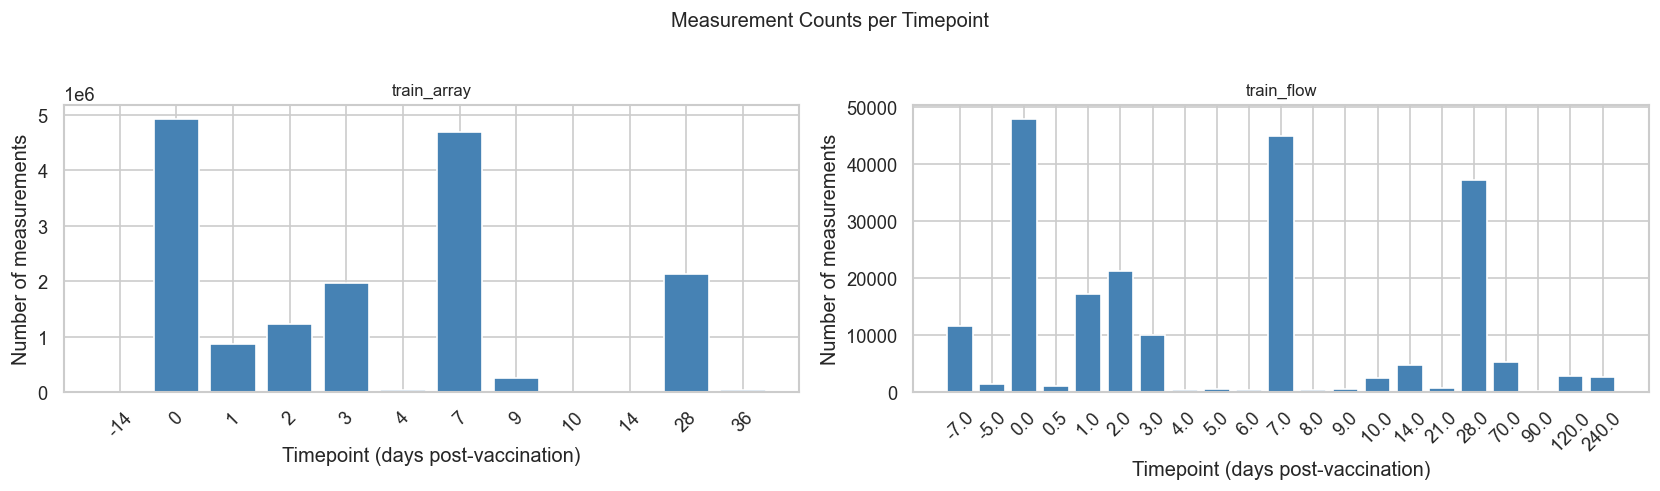

In [12]:
# Visualize timepoint distributions
tp_tables = {name: df for name, df in tables.items() if 'timepoint' in df.columns}

fig, axes = plt.subplots(1, len(tp_tables), figsize=(14, 4))

for ax, (name, df) in zip(axes, tp_tables.items()):
    tp_counts = df['timepoint'].value_counts().sort_index()
    ax.bar(tp_counts.index.astype(str), tp_counts.values, color='steelblue', edgecolor='white')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Timepoint (days post-vaccination)')
    ax.set_ylabel('Number of measurements')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Measurement Counts per Timepoint', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Participant Overlap Across Tables <a id='9'></a>

Not every participant will have data in all three tables. Knowing the overlap is essential before merging — participants missing from one table will become NaN rows in a join, which can silently break models.

In [13]:
ids = {name: set(df['participant_id']) for name, df in tables.items()}

print('Unique participants per table:')
for name, id_set in ids.items():
    print(f'  {name}: {len(id_set):,}')

print('\nPairwise overlaps:')
for (n1, s1), (n2, s2) in combinations(ids.items(), 2):
    overlap = len(s1 & s2)
    print(f'  {n1} ∩ {n2}: {overlap:,} shared participants')

all_three = ids['train_array'] & ids['train_flow'] & ids['train_participants']
print(f'\nParticipants present in ALL 3 tables: {len(all_three):,}')

Unique participants per table:
  train_array: 208
  train_flow: 264
  train_participants: 3,960

Pairwise overlaps:
  train_array ∩ train_flow: 45 shared participants
  train_array ∩ train_participants: 208 shared participants
  train_flow ∩ train_participants: 264 shared participants

Participants present in ALL 3 tables: 45


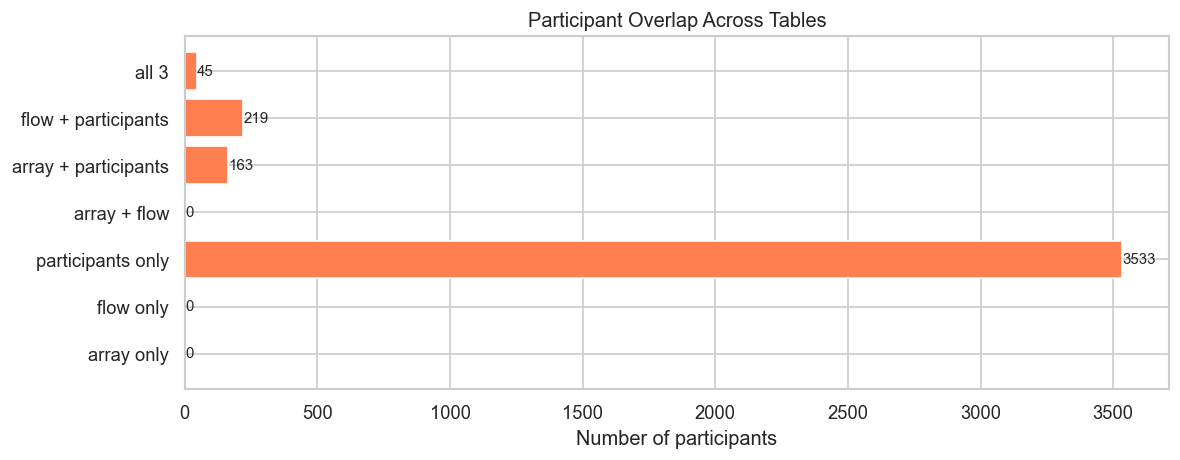

In [14]:
# Visualize overlap as a Venn-style bar chart
# (venn3 requires matplotlib-venn; this bar chart works without extra installs)
overlap_data = {
    'array only': len(ids['train_array'] - ids['train_flow'] - ids['train_participants']),
    'flow only': len(ids['train_flow'] - ids['train_array'] - ids['train_participants']),
    'participants only': len(ids['train_participants'] - ids['train_array'] - ids['train_flow']),
    'array + flow': len(ids['train_array'] & ids['train_flow'] - ids['train_participants']),
    'array + participants': len(ids['train_array'] & ids['train_participants'] - ids['train_flow']),
    'flow + participants': len(ids['train_flow'] & ids['train_participants'] - ids['train_array']),
    'all 3': len(all_three),
}

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(list(overlap_data.keys()), list(overlap_data.values()), color='coral', edgecolor='white')
ax.set_xlabel('Number of participants')
ax.set_title('Participant Overlap Across Tables')
for i, v in enumerate(overlap_data.values()):
    ax.text(v + 1, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 10. Longitudinal Subjects (Multi-Season Participants) <a id='10'></a>

`subject` and `participant_id` are different things. A single `subject` (person) can appear as multiple `participant_id` rows — once per flu season they were enrolled in. This is a key feature of the longitudinal design, but it means observations are **not independent** across seasons for the same subject.

In [15]:
# How many studies does each subject appear in?
subject_study_counts = (
    train_participants
    .groupby('subject')['investigation_id']
    .nunique()
    .sort_values(ascending=False)
)

print(f'Total unique subjects: {len(subject_study_counts):,}')
print(f'\nDistribution of how many studies each subject appears in:')
print(subject_study_counts.value_counts().sort_index().rename('n_subjects').to_string())

Total unique subjects: 2,498

Distribution of how many studies each subject appears in:
investigation_id
1    1921
2     209
3     119
4      82
5     105
6      33
7      19
8      10


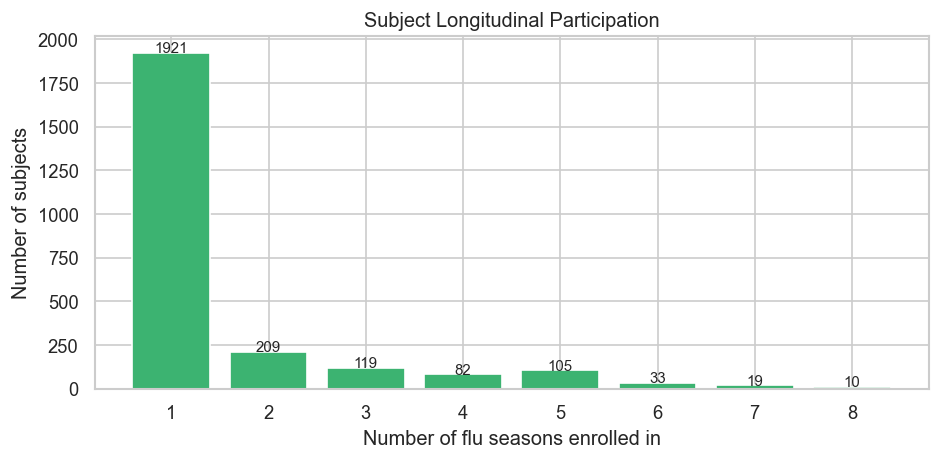

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
vc = subject_study_counts.value_counts().sort_index()
ax.bar(vc.index.astype(str), vc.values, color='mediumseagreen', edgecolor='white')
ax.set_xlabel('Number of flu seasons enrolled in')
ax.set_ylabel('Number of subjects')
ax.set_title('Subject Longitudinal Participation')
for i, (x, y) in enumerate(zip(vc.index, vc.values)):
    ax.text(i, y + 2, str(y), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 11. Participant Demographics <a id='11'></a>

Cohort composition overview — biological sex, race, age distribution, and geographic location.

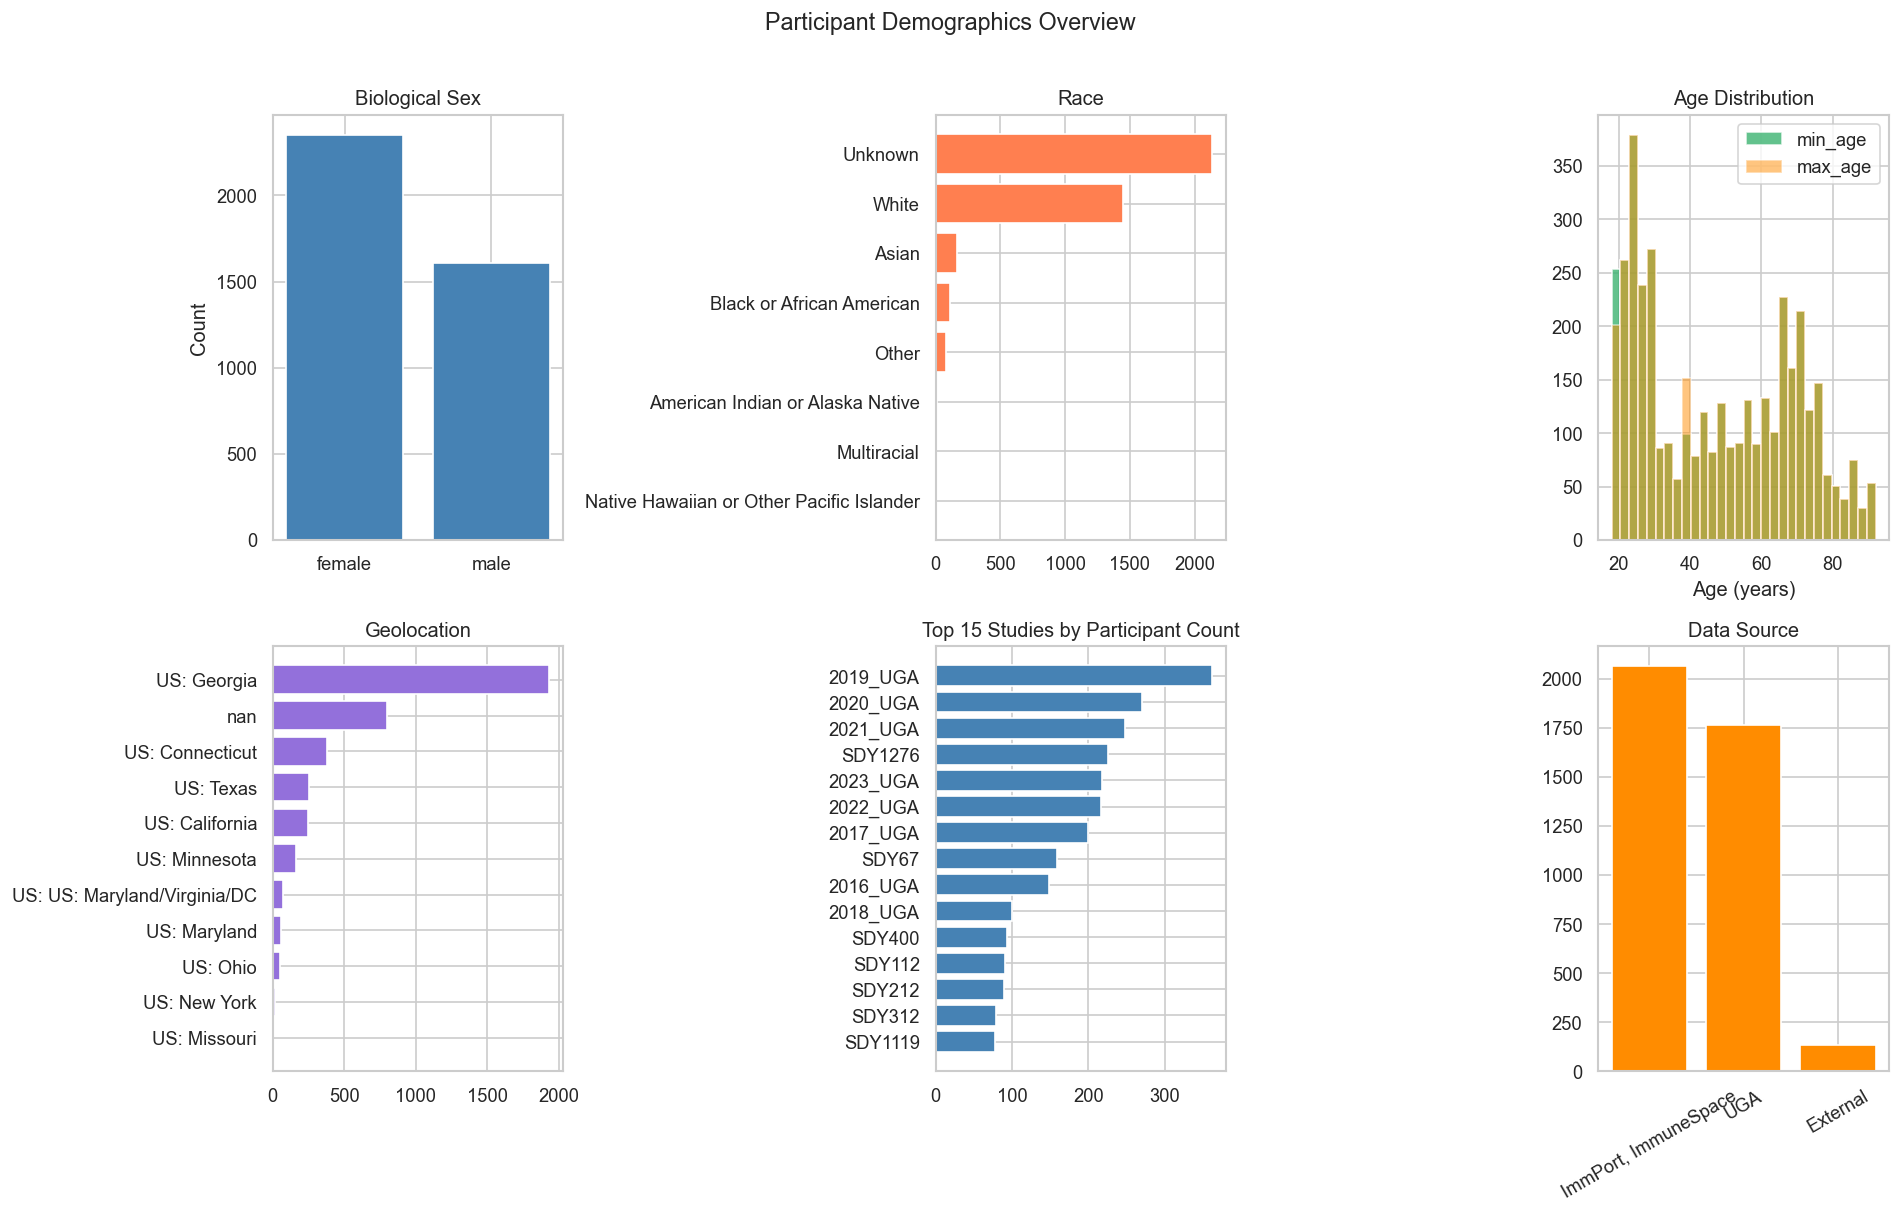

In [17]:
df_p = train_participants.copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# --- Biological Sex ---
ax = axes[0, 0]
vc = df_p['biological_sex'].value_counts(dropna=False)
ax.bar(vc.index.astype(str), vc.values, color='steelblue', edgecolor='white')
ax.set_title('Biological Sex')
ax.set_ylabel('Count')

# --- Race ---
ax = axes[0, 1]
vc = df_p['race'].value_counts(dropna=False)
ax.barh(vc.index.astype(str), vc.values, color='coral', edgecolor='white')
ax.set_title('Race')
ax.invert_yaxis()

# --- Age Distribution ---
ax = axes[0, 2]
ax.hist(df_p['min_age'], bins=30, color='mediumseagreen', edgecolor='white', alpha=0.8, label='min_age')
ax.hist(df_p['max_age'], bins=30, color='darkorange', edgecolor='white', alpha=0.5, label='max_age')
ax.set_title('Age Distribution')
ax.set_xlabel('Age (years)')
ax.legend()

# --- Geolocation ---
ax = axes[1, 0]
vc = df_p['geolocation'].value_counts(dropna=False)
ax.barh(vc.index.astype(str), vc.values, color='mediumpurple', edgecolor='white')
ax.set_title('Geolocation')
ax.invert_yaxis()

# --- Study (Investigation) Distribution ---
ax = axes[1, 1]
vc = df_p['investigation_id'].value_counts().head(15)
ax.barh(vc.index.astype(str), vc.values, color='steelblue', edgecolor='white')
ax.set_title('Top 15 Studies by Participant Count')
ax.invert_yaxis()

# --- Data Source ---
ax = axes[1, 2]
vc = df_p['data_source'].value_counts(dropna=False)
ax.bar(vc.index.astype(str), vc.values, color='darkorange', edgecolor='white')
ax.set_title('Data Source')
ax.tick_params(axis='x', rotation=30)

plt.suptitle('Participant Demographics Overview', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 12. Flow Cytometry — Unit-Stratified Distributions <a id='12'></a>

The `value` column in `train_flow` mixes different units (`cells/uL`, `percentage`, `percentile`, `ul`, `cells`). Plotting them together would be meaningless — we split by unit. Values are clipped at the 99th percentile to prevent extreme outliers from collapsing the scale.

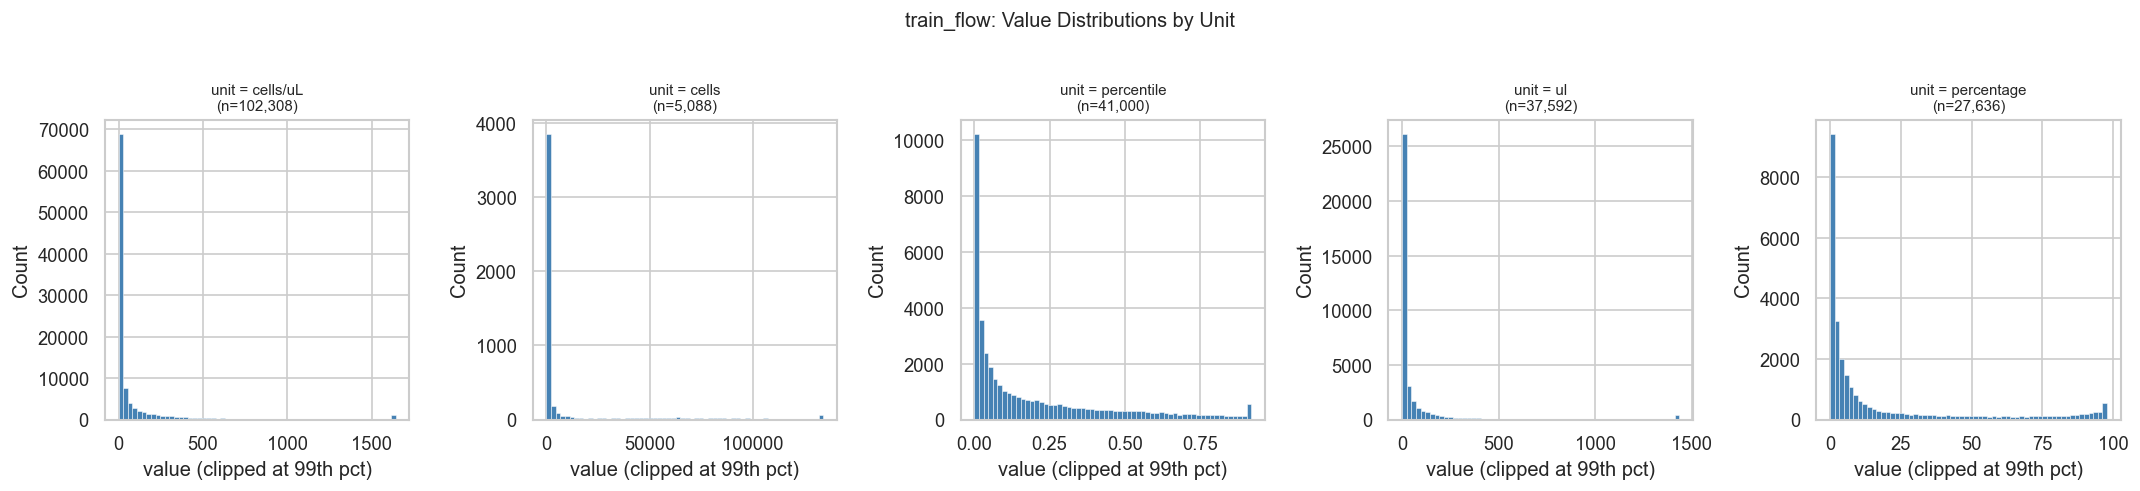

In [18]:
units = train_flow['unit'].dropna().unique()
fig, axes = plt.subplots(1, len(units), figsize=(18, 4))

for ax, unit in zip(axes, units):
    group = train_flow[train_flow['unit'] == unit]['value']
    clip_val = group.quantile(0.99)
    ax.hist(group.clip(upper=clip_val), bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.set_title(f'unit = {unit}\n(n={len(group):,})', fontsize=9)
    ax.set_xlabel('value (clipped at 99th pct)')
    ax.set_ylabel('Count')

plt.suptitle('train_flow: Value Distributions by Unit', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# Top cell populations by measurement count
print('Most frequently measured named cell populations:')
print(train_flow['name'].value_counts(dropna=False).head(15).to_string())

Most frequently measured named cell populations:
name
NaN                                                   83841
live CD45+ cells?                                     44126
CD4 T cells                                           20524
CD8 T cells                                           11007
Tfh CXCR5+ CD4 T cell                                  7095
Classical + Intermediate + non-classical monocytes     6572
Th1 CXCR3+ CD4 T cells                                 5300
T cells                                                4953
CD56hi + CD56+ NK cells                                4368
Conventional DCs                                       4214
Plasmacytoid DCs                                       4186
Memory class switched B cells                          3094
Naive B cells                                          2270
Memory class switched + non-class switched B cells     1788
Naive CD4 + Naive CD8 T cells                          1144


---
## 13. Gene Expression — Distribution by Platform <a id='13'></a>

The `train_array` table has 4 microarray platforms. Even though values are already log2-normalized, the distributions may differ across platforms — a sign of batch effects that would need correction (e.g., ComBat) before combining them for modeling.

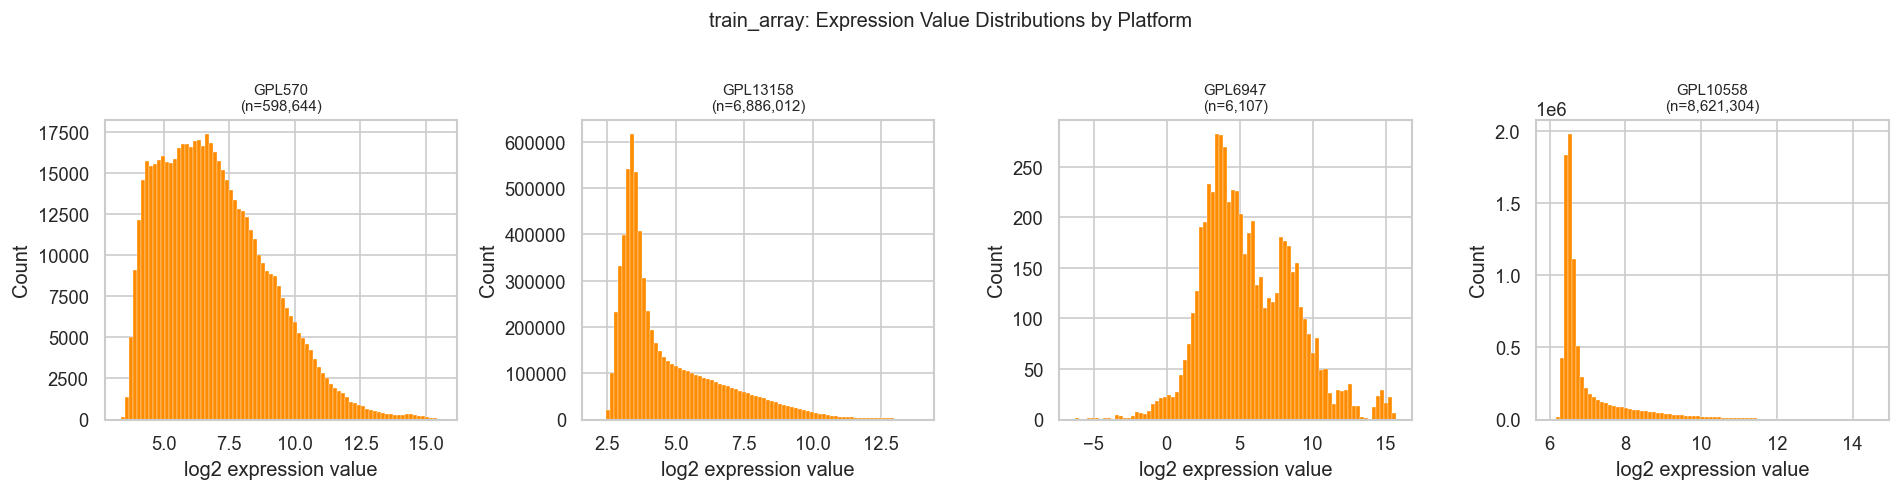

In [20]:
platforms = train_array['platform_id'].unique()
fig, axes = plt.subplots(1, len(platforms), figsize=(16, 4))

for ax, platform in zip(axes, platforms):
    group = train_array[train_array['platform_id'] == platform]['value'].dropna()
    ax.hist(group, bins=80, color='darkorange', edgecolor='white', linewidth=0.2)
    ax.set_title(f'{platform}\n(n={len(group):,})', fontsize=9)
    ax.set_xlabel('log2 expression value')
    ax.set_ylabel('Count')

plt.suptitle('train_array: Expression Value Distributions by Platform', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

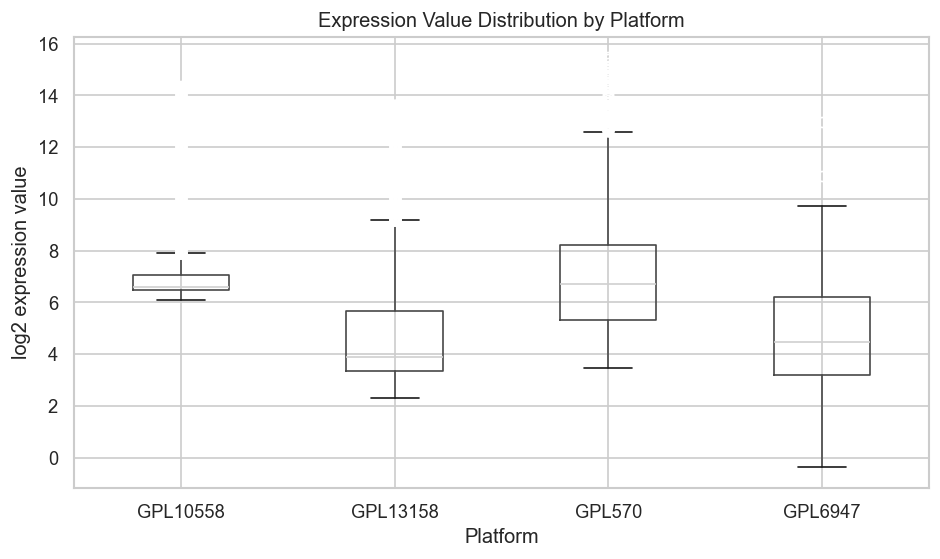

In [21]:
# Box plot: same distributions side-by-side makes scale differences clearer
sample_array = train_array.sample(min(200_000, len(train_array)), random_state=42)

fig, ax = plt.subplots(figsize=(8, 5))
sample_array.boxplot(column='value', by='platform_id', ax=ax)
ax.set_title('Expression Value Distribution by Platform')
ax.set_xlabel('Platform')
ax.set_ylabel('log2 expression value')
plt.suptitle('')  # suppress default pandas suptitle
plt.tight_layout()
plt.show()

---
## 14. Missing Value Heatmaps <a id='14'></a>

A visual map of WHERE missing values occur. Colored = data present, light/yellow = missing. Patterns (e.g., whole columns always missing) can indicate structural missingness rather than random dropout.

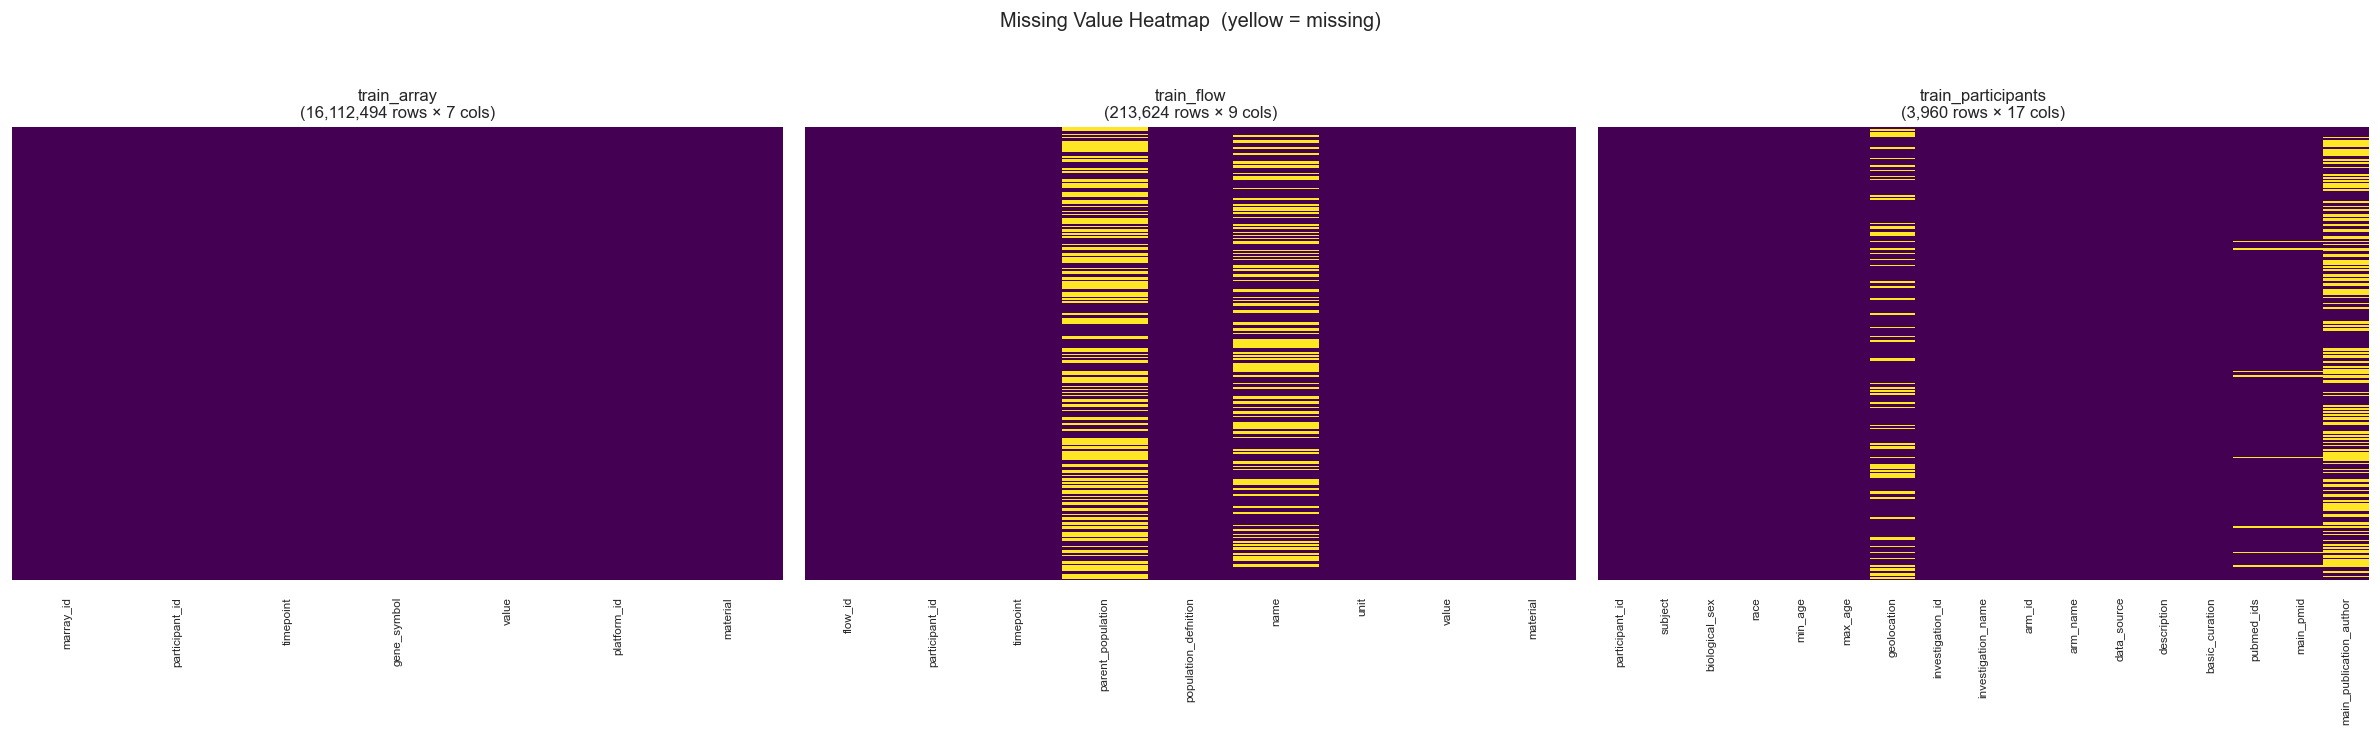

In [22]:
fig, axes = plt.subplots(1, len(tables), figsize=(20, 6))

for ax, (name, df) in zip(axes, tables.items()):
    # Sample rows if table is large, to keep the plot readable
    sample = df.sample(min(300, len(df)), random_state=42) if len(df) > 300 else df
    sns.heatmap(
        sample.isnull(),
        ax=ax,
        cbar=False,
        yticklabels=False,
        cmap='viridis'
    )
    ax.set_title(f'{name}\n({df.shape[0]:,} rows × {df.shape[1]} cols)', fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)

plt.suptitle('Missing Value Heatmap  (yellow = missing)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

---
## 15. Timepoint Deep-Dive <a id='15'></a>

Now that we know the timepoints in each table, we dig deeper:
- How many **participants** actually have data at each core timepoint?
- Which timepoints are **shared** between `train_array` and `train_flow` (relevant for multi-modal feature fusion)?
- Fix the one negative flow value by clipping to 0.

In [23]:
# Fix the single negative flow value (computed population, rounding artifact)
train_flow['value'] = train_flow['value'].clip(lower=0)
print(f'Negative flow values remaining: {(train_flow["value"] < 0).sum()}')

Negative flow values remaining: 0


In [24]:
# How many participants have data at each 'core' timepoint?
# The effective sample size at each timepoint is what matters for modeling.

core_tps_array = [-14, 0, 1, 3, 7, 28]
core_tps_flow = [-7, 0, 1, 7, 28, 70, 90]

print('Participants with data at each core timepoint (train_array):')
for tp in core_tps_array:
    n = train_array[train_array['timepoint'] == tp]['participant_id'].nunique()
    print(f'  Day {tp:>4}: {n:>4} participants')

print('\nParticipants with data at each core timepoint (train_flow):')
for tp in core_tps_flow:
    n = train_flow[train_flow['timepoint'] == tp]['participant_id'].nunique()
    print(f'  Day {tp:>4}: {n:>4} participants')

Participants with data at each core timepoint (train_array):
  Day  -14:    6 participants
  Day    0:  208 participants
  Day    1:   34 participants
  Day    3:  100 participants
  Day    7:  200 participants
  Day   28:   74 participants

Participants with data at each core timepoint (train_flow):
  Day   -7:  109 participants
  Day    0:  252 participants
  Day    1:  162 participants
  Day    7:  246 participants
  Day   28:  181 participants
  Day   70:   47 participants
  Day   90:    1 participants


In [25]:
# Which timepoints are shared between train_array and train_flow?
# These are the timepoints where multi-modal analysis (gene expression + cell populations)
# is possible — important for feature engineering.

array_tps = set(train_array['timepoint'].unique())
flow_tps = set(int(t) for t in train_flow['timepoint'].unique())  # cast float→int for comparison
shared_tps = sorted(array_tps & flow_tps)
only_array = sorted(array_tps - flow_tps)
only_flow = sorted(set(train_flow['timepoint'].unique()) - set(float(t) for t in array_tps))

print(f'Timepoints in BOTH tables (multi-modal analysis possible): {shared_tps}')
print(f'Timepoints only in train_array:  {only_array}')
print(f'Timepoints only in train_flow:   {[round(t, 1) for t in only_flow]}')


Timepoints in BOTH tables (multi-modal analysis possible): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(7), np.int64(9), np.int64(10), np.int64(14), np.int64(28)]
Timepoints only in train_array:  [np.int64(-14), np.int64(36)]
Timepoints only in train_flow:   [np.float64(-7.0), np.float64(-5.0), np.float64(0.5), np.float64(5.0), np.float64(6.0), np.float64(8.0), np.float64(21.0), np.float64(70.0), np.float64(90.0), np.float64(120.0), np.float64(240.0)]


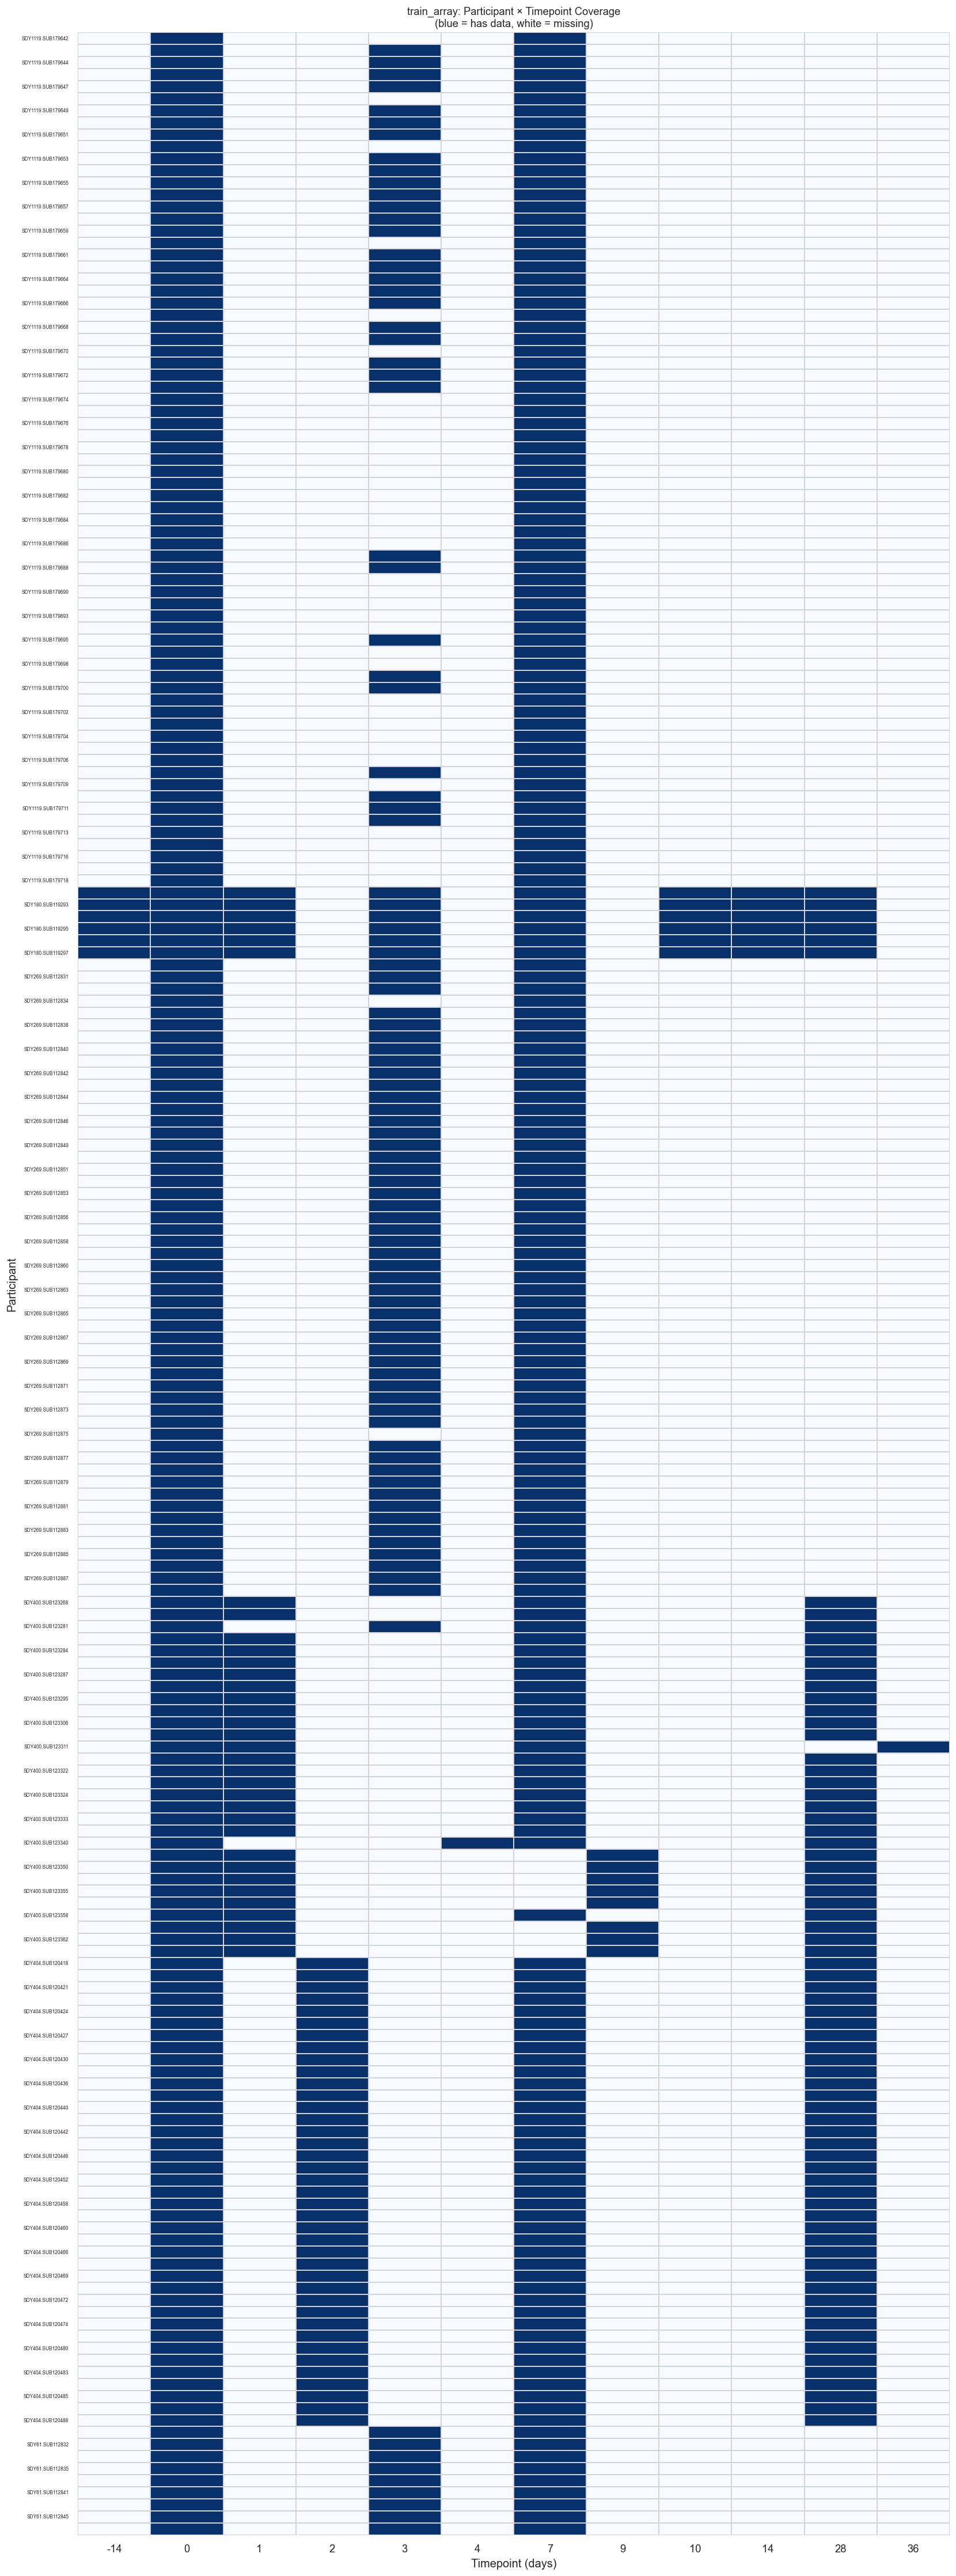


Participants with data at ALL of days [0, 7, 28]: 66 / 208


In [26]:
# Heatmap: participant × timepoint coverage for train_array
# Each cell = number of genes measured for that participant at that timepoint.
# Gaps (white) = missing data — important for imputation decisions.

# Pivot: rows = participants, cols = timepoints, values = gene measurement count
array_coverage = (
    train_array
    .groupby(['participant_id', 'timepoint'])['gene_symbol']
    .count()
    .unstack(fill_value=0)
)

# Binarize for readability: 1 = has data, 0 = missing
array_coverage_bin = (array_coverage > 0).astype(int)

fig, ax = plt.subplots(figsize=(14, max(6, len(array_coverage_bin) * 0.18)))
sns.heatmap(
    array_coverage_bin,
    ax=ax,
    cmap='Blues',
    cbar=False,
    linewidths=0.2,
    linecolor='lightgrey'
)
ax.set_title('train_array: Participant × Timepoint Coverage\n(blue = has data, white = missing)', fontsize=11)
ax.set_xlabel('Timepoint (days)')
ax.set_ylabel('Participant')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=5)
plt.tight_layout()
plt.show()

# Summary: what fraction of participants have complete core timepoints?
core = [0, 7, 28]
has_core = array_coverage_bin[core].all(axis=1)
print(f'\nParticipants with data at ALL of days {core}: {has_core.sum()} / {len(has_core)}')

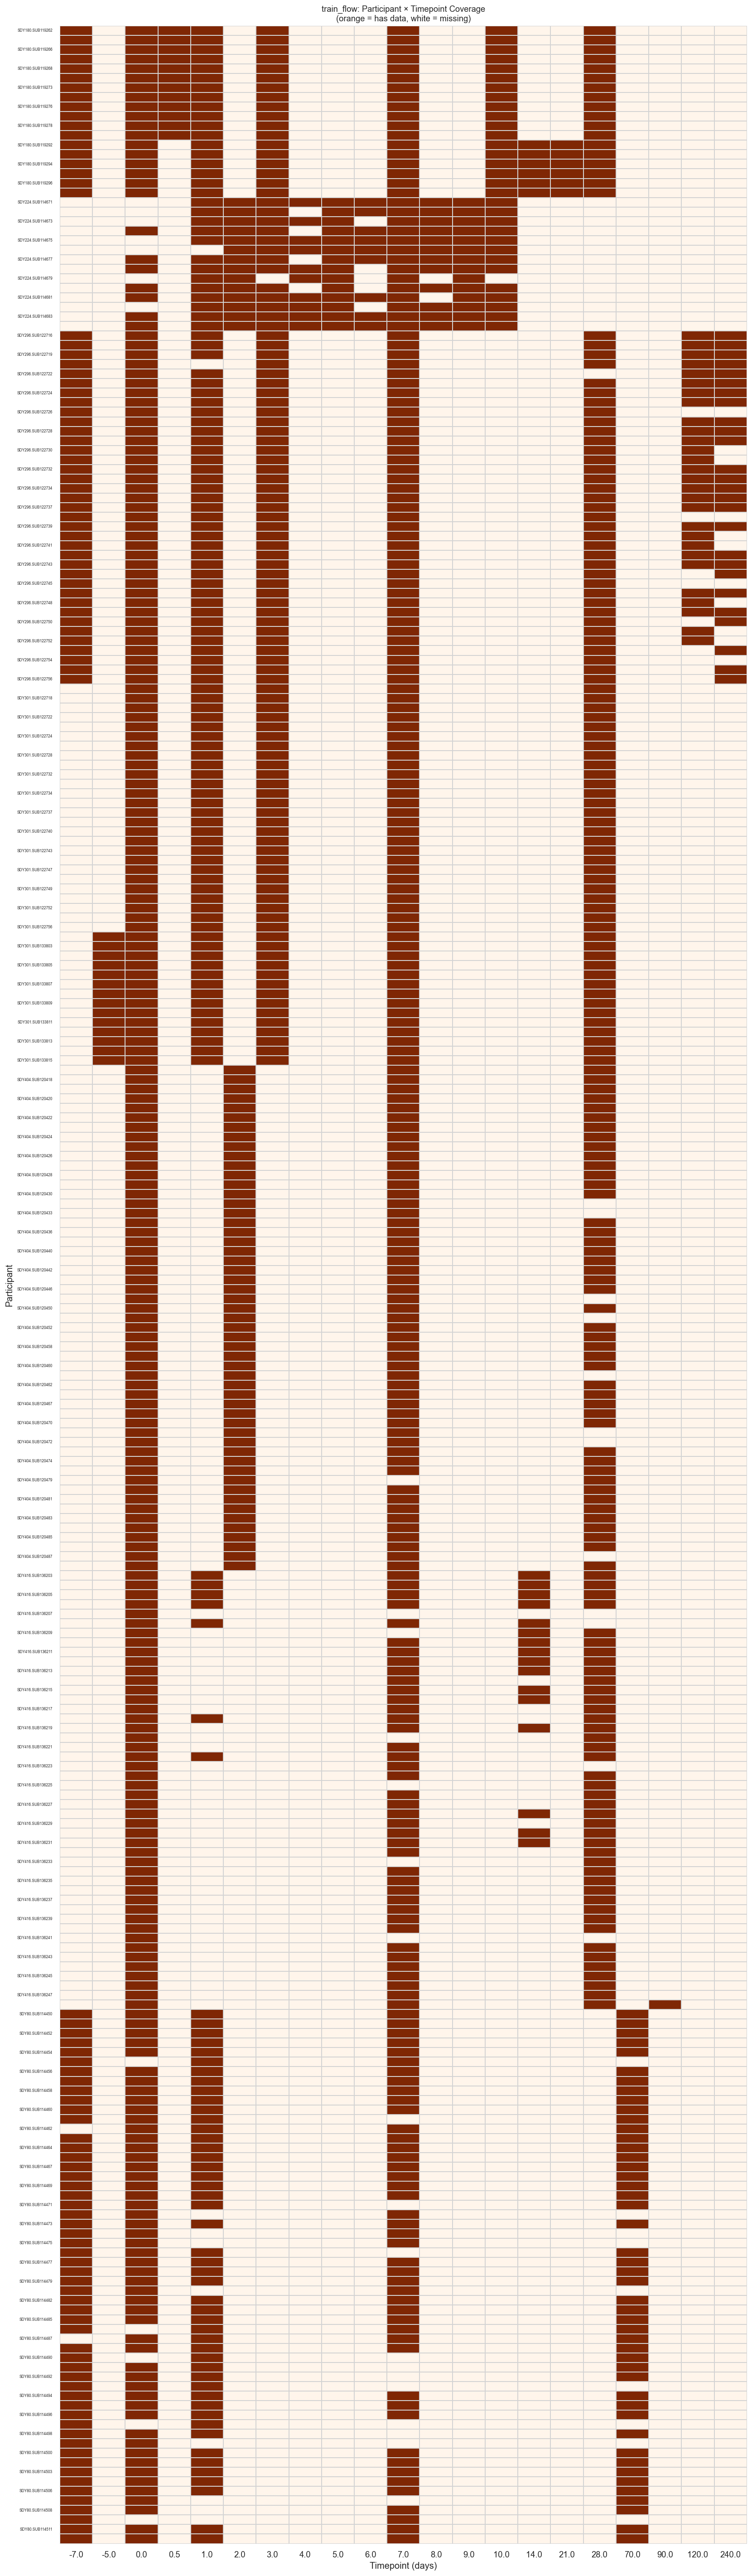


Participants with data at ALL of days [0, 7, 28]: 176 / 264


In [27]:
# Same coverage heatmap for train_flow

flow_coverage = (
    train_flow
    .groupby(['participant_id', 'timepoint'])['flow_id']
    .count()
    .unstack(fill_value=0)
)
flow_coverage_bin = (flow_coverage > 0).astype(int)

fig, ax = plt.subplots(figsize=(14, max(6, len(flow_coverage_bin) * 0.18)))
sns.heatmap(
    flow_coverage_bin,
    ax=ax,
    cmap='Oranges',
    cbar=False,
    linewidths=0.2,
    linecolor='lightgrey'
)
ax.set_title('train_flow: Participant × Timepoint Coverage\n(orange = has data, white = missing)', fontsize=11)
ax.set_xlabel('Timepoint (days)')
ax.set_ylabel('Participant')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=5)
plt.tight_layout()
plt.show()

core_flow = [0, 7, 28]
available_core = [c for c in core_flow if c in flow_coverage_bin.columns]
has_core_flow = flow_coverage_bin[available_core].all(axis=1)
print(f'\nParticipants with data at ALL of days {available_core}: {has_core_flow.sum()} / {len(has_core_flow)}')

---
## 16. EDA Summary & Key Findings <a id='16'></a>

### What we found

| Finding | Detail | Implication |
|---|---|---|
| **Very limited multi-modal overlap** | Only **45 participants** appear in all 3 tables | Most modeling will need to treat array and flow as separate datasets unless you restrict to this small subset |
| **train_array is dominated by days 0 and 7** | Day 0: 208 participants, Day 7: 200 — but Day 28: only 74 | Many participants are missing late timepoints; imputation or analysis restricted to days 0 and 7 may be needed |
| **train_flow has better longitudinal coverage** | 176/264 participants have days 0, 7, and 28 | Flow data is more complete for longitudinal modeling |
| **train_participants is metadata-only** | 3,960 rows but only 208/264 have assay data | Useful for demographic stratification but cannot stand alone for prediction |
| **4 microarray platforms in train_array** | GPL10558 dominates (~8.6M rows); GPL6947 is tiny (~6k rows) | Batch correction (e.g., ComBat) is likely needed before cross-platform modeling |
| **Mixed units in train_flow** | 5 unit types: `cells/uL`, `percentage`, `percentile`, `ul`, `cells` | Always filter by `unit` before aggregating; never mix units in a model feature |
| **train_participants skews female, mostly Unknown race** | 59% female; 54% race Unknown | Class imbalance in demographics; Unknown race limits subgroup analyses |
| **Longitudinal subjects** | 577 subjects appear in 2+ flu seasons (up to 8) | Must use subject-level grouping for cross-validation splits — **do not split by participant_id** |

### Recommended next steps
- **Batch correction**: Apply ComBat or similar to `train_array` across the 4 platforms before feature extraction
- **Unit-stratified analysis**: Always keep `unit` as a filter when working with `train_flow`
- **Cross-validation strategy**: Group by `subject` (not `participant_id`) when doing train/val splits to prevent data leakage across flu seasons
- **Dimensionality reduction**: With 39,665 genes × 208 participants, consider filtering to high-variance genes before pivoting to wide format


---
## 17. Export Cleaned Data <a id='17'></a>

Uncomment and run to save the cleaned versions of each table.
All cleaning steps applied in this notebook are already reflected in the in-memory DataFrames:
- `train_participants`: `biological_sex` normalized to lowercase, race categories consolidated
- `train_flow`: negative `value` clipped to 0
- `train_array`: unchanged (the 427 NaN values in `value` are left as-is for downstream handling)

In [28]:


# # ── CONFIGURE OUTPUT PATH ────────────────────────────────────────────────────
# # Change this to wherever you want the cleaned files saved.
# OUTPUT_PATH = DATA_PATH  # saves alongside originals; change if preferred
# os.makedirs(OUTPUT_PATH, exist_ok=True)

# # ── EXPORT train_participants_cleaned ────────────────────────────────────────
# # Changes: biological_sex lowercased, race categories consolidated
# train_participants.to_csv(
#     os.path.join(OUTPUT_PATH, 'train_participants_cleaned.csv'),
#     index=False
# )
# print(f'Saved train_participants_cleaned.csv  ({train_participants.shape[0]:,} rows)')

# # ── EXPORT train_flow_cleaned ────────────────────────────────────────────────
# # Changes: negative value clipped to 0
# # NOTE: if you want to filter to a single unit type before saving, do it here:
# #   e.g. train_flow[train_flow['unit'] == 'cells/uL'].to_csv(...)
# train_flow.to_csv(
#     os.path.join(OUTPUT_PATH, 'train_flow_cleaned.csv'),
#     index=False
# )
# print(f'Saved train_flow_cleaned.csv  ({train_flow.shape[0]:,} rows)')

# # ── EXPORT train_array_cleaned ───────────────────────────────────────────────
# # Changes: none applied during EDA — NaN values in 'value' preserved
# # NOTE: This file is ~16M rows. Saving as TSV is faster and more compact than CSV for large files.
# # Option A: save as TSV (matches original format, more efficient)
# train_array.to_csv(
#     os.path.join(OUTPUT_PATH, 'train_array_cleaned.tsv'),
#     sep='\t', index=False
# )
# print(f'Saved train_array_cleaned.tsv  ({train_array.shape[0]:,} rows)')
#
# # Option B: save as parquet instead (much faster read/write, smaller file, recommended for large data)
# # train_array.to_parquet(
# #     os.path.join(OUTPUT_PATH, 'train_array_cleaned.parquet'), index=False
# # )
# # print(f'Saved train_array_cleaned.parquet  ({train_array.shape[0]:,} rows)')

# print('\nAll exports complete.')
